In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc

In [ ]:

#this is path to the dataset and the dataset is getting loaded using pandas
path = "/content/spambase.data"
df = pd.read_csv(path, header=None)

In [ ]:

#these are all the columns from the spambase .names file
feat = ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$',
    'char_freq_#', 'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total', 'spam']

df.columns = feat
# we take all features in X and drop all columns except spam for y
X = df.drop('spam', axis=1).values
y = df['spam'].values

In [ ]:
# we split the data into 75 percent training and 25 percent testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)







In [ ]:

# 3.1


print("3.1 ")
# here I am storing list of k values
k_li = [1, 3, 5, 7, 9, 11, 15]

bestkValue = None
bestErrorSc = 1.0

for i in k_li:
  # for each k value I initialize model and then find accuracy, precision , recall and error
    mod1 = KNeighborsClassifier(n_neighbors=i)
    a = cross_val_score(mod1, X_train, y_train, cv=5, scoring='accuracy').mean()
    p = cross_val_score(mod1, X_train, y_train, cv=5, scoring='precision').mean()
    r = cross_val_score(mod1, X_train, y_train, cv=5, scoring='recall').mean()
    e = 1 - a


    print("k= " + str(i))
    print(" accuracy = "+ str(a)+ " error = "+ str(e) + " precision = "+ str(p) + " recall = " + str(r))
    print()
    # here I check if error is less then the best error if yes then store it in best error and store that k value in  best k
    if e < bestErrorSc:
        bestErrorSc = e
        bestkValue = i

print(f"The best value of k is is" + str(bestkValue) + " and the lowest error is "+ str(bestErrorSc))

3.1 - kNN Cross Validation
k= 1
 accuracy = 0.8052173913043479 error = 0.19478260869565212 precision = 0.7520028056393351 recall = 0.7429314103639107

k= 3
 accuracy = 0.7997101449275362 error = 0.20028985507246377 precision = 0.748601202853006 recall = 0.7287355358041255

k= 5
 accuracy = 0.7924637681159421 error = 0.2075362318840579 precision = 0.7419680988753785 recall = 0.7137822125328415

k= 7
 accuracy = 0.7869565217391303 error = 0.21304347826086967 precision = 0.7330969420166694 recall = 0.7093018055788474

k= 9
 accuracy = 0.7866666666666666 error = 0.21333333333333337 precision = 0.7317494453455504 recall = 0.7107831628374979

k= 11
 accuracy = 0.7831884057971014 error = 0.21681159420289864 precision = 0.7283074859136536 recall = 0.7040471798311811

k= 15
 accuracy = 0.773623188405797 error = 0.22637681159420298 precision = 0.7140970579172825 recall = 0.6943484823075632

The best value of k is is1 and the lowest error is 0.19478260869565212


In [ ]:
# 3.2
print("3.2")

#here I initialize 3 models one for Logistic Regression, LDA and KNN
mod1 = LogisticRegression(max_iter=1000)
mod2 = LinearDiscriminantAnalysis()
mod3 = KNeighborsClassifier(n_neighbors=bestkValue)

mod1.fit(X_train, y_train)
mod2.fit(X_train, y_train)
mod3.fit(X_train, y_train)

print("This is for Training Data:")

# first for training data for each model I find accuracy, error, precison and recall
models = {"Logistic Regression": mod1, "LDA": mod2, "kNN": mod3}
for name in models:
    predictedValue = models[name].predict(X_train)
    a_train = accuracy_score(y_train, predictedValue)
    e_train = 1 - a_train
    p_train = precision_score(y_train, predictedValue)
    r_train = recall_score(y_train, predictedValue)
    print(name)
    print(" accuracy= "+ str(a_train)+ " error= "+ str(e_train) + " precision= "+ str(p_train) + " recall= " + str(r_train))
    print()

print("This is for Testing Data:")

# Then for testing data for each model I find accuracy, error, precison and recall

models = {"LogReg": mod1, "LDA": mod2, "kNN": mod3}
for name in models:

    predictedValue = models[name].predict(X_test)
    a_test = accuracy_score(y_test, predictedValue)
    e_test = 1 - a_test
    p_test = precision_score(y_test, predictedValue)
    r_test = recall_score(y_test, predictedValue)
    print(name)
    print(" accuracy= "+ str(a_test)+ " error= "+ str(a_test) + " precision= "+ str(p_test) + " recall= " + str(r_test))
    print()


3.2 - Comparing Classifiers


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


This is for Training Data:
Logistic Regression
 accuracy= 0.9292753623188406 error= 0.07072463768115944 precision= 0.9266770670826833 recall= 0.8878923766816144

LDA
 accuracy= 0.8866666666666667 error= 0.11333333333333329 precision= 0.9157155399473222 recall= 0.7795216741405082

kNN
 accuracy= 0.9994202898550725 error= 0.0005797101449275255 precision= 0.9992526158445441 recall= 0.9992526158445441

This is for Testing Data:
LogReg
 accuracy= 0.9270199826238054 error= 0.9270199826238054 precision= 0.9413092550790068 recall= 0.8778947368421053

LDA
 accuracy= 0.8853171155516942 error= 0.8853171155516942 precision= 0.9298245614035088 recall= 0.7810526315789473

kNN
 accuracy= 0.8001737619461338 error= 0.8001737619461338 precision= 0.7578947368421053 recall= 0.7578947368421053




3.3 - ROC Curve (sklearn)
AUC = 0.9740
Threshold = 0: False Positive Rate = 1.0, True Positive Rate = 1.0
Threshold = 0.1: False Positive Rate = 0.3150887573964497, True Positive Rate = 0.9852631578947368
Threshold = 0.2: False Positive Rate = 0.17011834319526628, True Positive Rate = 0.9705263157894737
Threshold = 0.3: False Positive Rate = 0.09615384615384616, True Positive Rate = 0.9431578947368421
Threshold = 0.4: False Positive Rate = 0.06360946745562131, True Positive Rate = 0.9157894736842105
Threshold = 0.5: False Positive Rate = 0.038461538461538464, True Positive Rate = 0.8778947368421053
Threshold = 0.6: False Positive Rate = 0.03254437869822485, True Positive Rate = 0.8273684210526315
Threshold = 0.7: False Positive Rate = 0.02514792899408284, True Positive Rate = 0.7873684210526316
Threshold = 0.8: False Positive Rate = 0.01775147928994083, True Positive Rate = 0.7115789473684211
Threshold = 0.9: False Positive Rate = 0.013313609467455622, True Positive Rate = 0.585263157

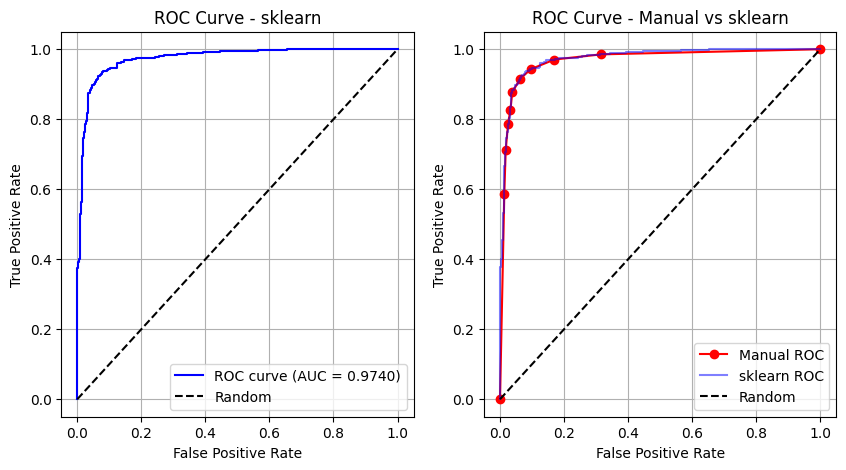

In [ ]:

# 3.3
print("\n3.3 - ROC Curve (sklearn)")
probs = mod1.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc_score = auc(fpr, tpr)
print(f"AUC = {auc_score:.4f}")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, 'b-', label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - sklearn')
plt.legend()
plt.grid(True)



# 3.4


# This has a list fo threshold values

tLi = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# We use li1 to store false positive rate for each threshold
li1 = []
# We use li2 to store true positive rate for each threshold
li2 = []

for t in tLi:
    tp = 0
    fp = 0
    fn = 0
    tn = 0
    for i in range(len(y_test)):
        if probs[i] >= t:
            pred = 1
        else:
            pred = 0

        if pred == 1 and y_test[i] == 1:
            tp += 1
        elif pred == 1 and y_test[i] == 0:
            fp += 1
        elif pred == 0 and y_test[i] == 1:
            fn += 1
        else:
            tn += 1

    # This is false positive rate for current threshold
    fr = fp / (fp + tn)

    # This is true positive rate for current threshold
    tr = tp / (tp + fn)

    li1.append(fr)
    li2.append(tr)
    print("Threshold = " + str(t) + ": False Positive Rate = " + str(fr) + ", True Positive Rate = " + str(tr))

plt.subplot(1, 2, 2)

plt.plot(li1, li2, color='red', marker='o', label='Manual ROC')

plt.plot(fpr, tpr, color='blue', alpha=0.5, label='sklearn ROC')

plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve - Manual vs sklearn')
plt.legend()
plt.grid(True)

